## **Finding Duplicates Lab**
## Introduction

Data wrangling is a critical step in preparing datasets for analysis, and handling duplicates plays a key role in ensuring data accuracy. In this Project, we will focus on identifying and removing duplicate entries from your dataset.

## Objectives

1. Identify duplicate rows in the dataset and analyze their characteristics.
2. Visualize the distribution of duplicates based on key attributes.
3. Remove duplicate values strategically based on specific criteria.
4. Outline the process of verifying and documenting duplicate removal.

Install the Library 

for this project we will be using pandas and matplotlib

In [1]:
!pip install pandas
!pip install matplotlib

Import pandas module
Import matplotlib

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

## **Load the dataset into a dataframe**


In [3]:
# Load the dataset directly from the URL
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/VYPrOu0Vs3I0hKLLjiPGrA/survey-data-with-duplicate.csv"
df = pd.read_csv(file_path)

# Display the first few rows

print(df.head())

   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

## Identify Duplicate Rows
Count the number of duplicate rows in the dataset.
Display the first few duplicate rows to understand their structure.

In [4]:
# Count duplicate rows
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)
# Display duplicate rows
duplicates = df[df.duplicated()]
duplicates.head()

Number of duplicate rows: 20


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
65437,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65438,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
65439,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
65440,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
65441,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


## Analysis of Duplicate Response Patterns
1. Identify duplicate response patterns based on selected columns such as MainBranch, Employment, and RemoteWork.
2. Clarify that these represent multiple respondents with identical answers rather than duplicate records. Analyse which other columns frequently share identical values within these response-pattern groups.Analysis of Duplicate Response Patterns

In [8]:
#groupby([...]) groups respondents by the selected columns
#.size() counts how many rows per group
#.reset_index(name='Count') turns it into a clean table with a Count column

pattern_counts = df.groupby(['MainBranch','Employment','RemoteWork']).size().reset_index(name='Count')

#Sorts results from most common pattern → least common
pattern_counts = pattern_counts.sort_values(by='Count', ascending=False)

#Shows the top 5 most common patterns
pattern_counts.head()

,MainBranch,Employment,RemoteWork,Count
0,I am a developer by profession,"Employed, full-time","Hybrid (some remote, some in-person)",15288
2,I am a developer by profession,"Employed, full-time",Remote,12196
1,I am a developer by profession,"Employed, full-time",In-person,7118
78,I am a developer by profession,"Independent contractor, freelancer, or self-em...",Remote,2815
8,I am a developer by profession,"Employed, full-time;Independent contractor, fr...",Remote,1754


 “Filtered the dataset to isolate repeated response patterns and analyzed additional attributes within these groups to identify common characteristics such as geographic distribution, technical skills, and experience levels.”

In [9]:
#Keep only groups with more than 1 respondent
duplicate_patterns = (
    df.groupby(['MainBranch', 'Employment', 'RemoteWork'])
      .filter(lambda x: len(x) > 1)
)

duplicate_patterns.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
6,7,"I am not primarily a developer, but I write co...",35-44 years old,"Employed, full-time",Remote,Apples,I don’t code outside of work,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)","Other online resources (e.g., videos, blogs, f...",Technical documentation;Stack Overflow;Written...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Neither easy nor difficult,NaN,NaN
8,9,I code primarily as a hobby,45-54 years old,"Employed, full-time",In-person,Apples,Hobby,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",Books / Physical media;Other online resources ...,Stack Overflow;Written-based Online Courses,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Neither easy nor difficult,NaN,NaN


This filtered dataset contains only respondents who share the same combination of answers.
It removes unique profiles and focuses on common response groups.


## Visualize Shared Response Patterns
1. Create visualizations to show the distribution of shared response patterns across different categories.
2. Use bar charts or pie charts to represent the distribution of respondents who share identical values for MainBranch, Employment, and RemoteWork, grouped by Country and Employment.

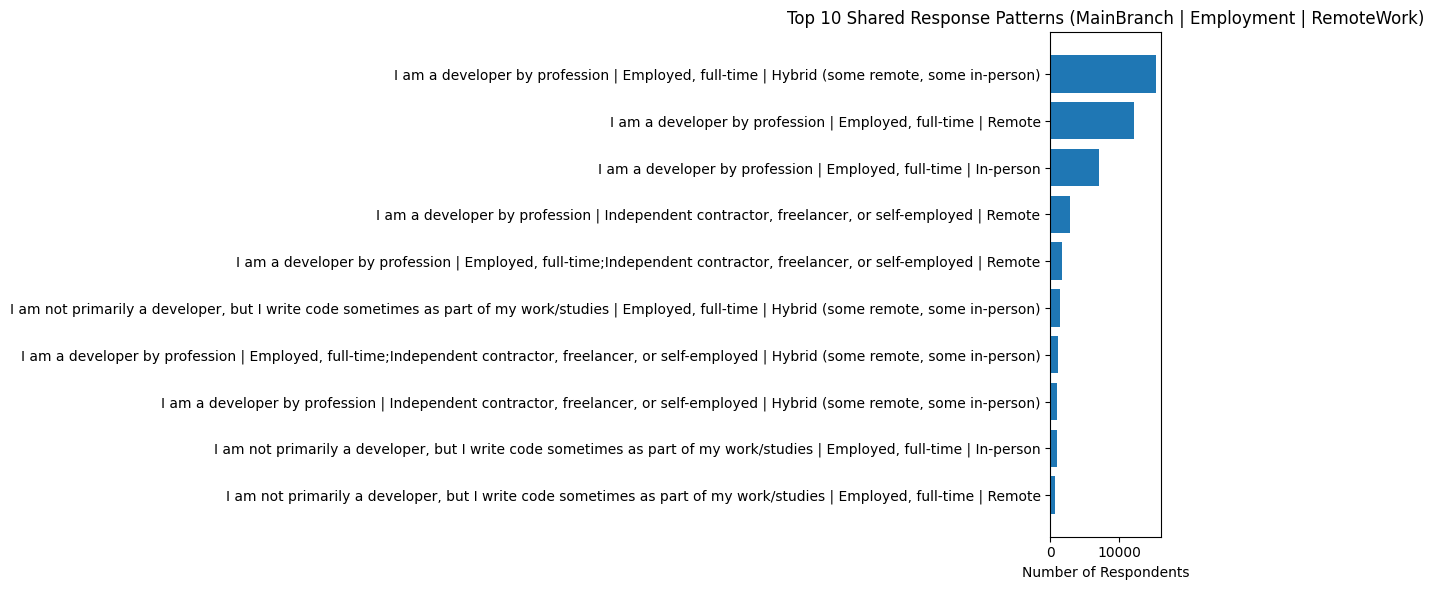

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Define the columns that make up a response pattern.
# These are the answers we want to compare across respondents.
pattern_cols = ['MainBranch', 'Employment', 'RemoteWork']

# Group the dataset by the selected pattern columns.
# .size() counts how many respondents share each exact combination of answers.
# .reset_index(name='Count') turns the grouped result into a regular DataFrame
# and names the count column "Count".
# .sort_values(...) orders the patterns from most common to least common.
pattern_counts = (
    df.groupby(pattern_cols)
      .size()
      .reset_index(name='Count')
      .sort_values('Count', ascending=False)
)

# Choose how many of the most common shared patterns to display in the chart.
top_n = 10

# Keep only the top 10 most frequent response patterns.
# .copy() creates a separate DataFrame so it is safe to modify.
top_patterns = pattern_counts.head(top_n).copy()

# Create one readable label for each pattern by combining the three columns.
# This makes the y-axis easier to understand in the bar chart.
top_patterns['Pattern'] = (
    top_patterns['MainBranch'].astype(str) + " | " +
    top_patterns['Employment'].astype(str) + " | " +
    top_patterns['RemoteWork'].astype(str)
)

# Create the figure and set its size.
# A wider figure helps fit long text labels.
plt.figure(figsize=(12, 6))

# Draw a horizontal bar chart.
# [::-1] reverses the order so the largest values appear at the top visually.
plt.barh(top_patterns['Pattern'][::-1], top_patterns['Count'][::-1])

# Label the x-axis to show what the bar values represent.
plt.xlabel('Number of Respondents')

# Add a chart title describing what is being displayed.
plt.title(f'Top {top_n} Shared Response Patterns (MainBranch | Employment | RemoteWork)')

# Automatically adjust spacing so labels and title fit neatly.
plt.tight_layout()

# Display the finished chart.
plt.show()

## **Evaluate Duplicate Handling Strategy**
1. Analyse the dataset to determine which column(s) define record uniqueness.
2. Assess whether removing rows based on a subset of columns (rather than complete row duplication) is appropriate.
Justify your decision with reference to the structure and purpose of the dataset.


This data represents survey responses where each row coresponds to an individual respondent. Columns such as MainBranch, Employment, and RemoteWork this describes characteristics of respondents but do not uniquely identify a record. Multiple respondents may share the same values in this field, so using them to remove duplicates would incorrectly eliminate a valid response. A better approach is to rely on unique identifier such as respondents ID is availabe. If no such identifier found, duplicate detection sshold be limited to entirely identical rows, this ensures that the only accedental duplicate records are removed while preserving legitimate survey responses and maintaining the interity of the dataset for accurate analysis.

## **Documentation**
1. Document the process of identifying and removing duplicates.


Based on my analysis, the process of identifyying duplicated began by using `duplicated()` function in pandas to detect rows that were exact match across all columns, this step will help me verify if duplicated records exists in the data set and allowed me a quict inspection for those rows. After confirmation of the duplicates, the `drop_duplicates()` function is applied to remove the repeated records while keeping the first record, this ensure that only unintended duplicate records were removed, the approach is focused on  full row duplication rather than selecting columns this is to avoid mistakenly deliting valid survey responses were multiple respondeds may share similar inputs. This process helps me to maintain the accuracy annd integrity of the dataset.

2. Explain the reasoning behind selecting specific columns for identifying and removing duplicates.

The selection of columns for identifying duplicates was based on the structure of the survey dataset. Columns such as MainBranch, Employment, and RemoteWork describe respondent characteristics but do not uniquely identify a record. Many respondents may legitimately share the same values in these fields, so using them alone to remove duplicates could result in the loss of valid data. Instead, duplicate detection was performed using complete row comparison, ensuring that only records with identical values across all columns were treated as duplicates. This approach helps prevent the accidental removal of legitimate survey responses while ensuring that true duplicate entries are properly identified and removed to maintain data accuracy.